In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Plot configuration
sns.set_theme(rc={'figure.dpi': 300})

In [2]:
df = pd.read_csv("clean_dataset.csv")
df

,record_date,avg_temp,hi_temp,low_temp,out_hum,dew_pt,wind_speed,wind_direction,wind_run,hi_speed,...,in_hum,in_dew,in_heat,in_emc,in_air_density,et,wind_samp,wind_tx,iss_recept,arc_int
0,2008-01-18 03:45:00,15.0,15.0,14.9,74.0,10.4,0.0,Calm,0.0,0.0,...,43.0,12.9,26.0,8.05,1.1588,0.00,351,1,100.0,15
1,2008-01-18 04:00:00,14.8,15.0,14.7,75.0,10.4,0.0,Calm,0.0,0.0,...,44.0,13.1,25.9,8.16,1.1588,0.03,352,1,100.0,15
2,2008-01-18 04:15:00,14.5,14.7,14.4,76.0,10.3,0.0,Calm,0.0,0.0,...,44.0,13.0,25.8,8.17,1.1597,0.00,351,1,100.0,15
3,2008-01-18 04:30:00,14.3,14.4,14.3,76.0,10.2,0.0,S,0.0,1.6,...,44.0,12.9,25.7,8.17,1.1602,0.00,351,1,100.0,15
4,2008-01-18 04:45:00,14.2,14.3,14.1,76.0,10.0,0.0,Calm,0.0,0.0,...,44.0,12.8,25.6,8.18,1.1609,0.00,351,1,100.0,15
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
634330,2026-05-18 18:45:00,15.6,16.7,15.6,18.0,-8.7,1.6,SSW,0.4,6.4,...,28.0,-0.7,16.0,5.96,1.2076,0.00,352,1,100.0,15
634331,2026-05-18 19:00:00,14.8,15.6,14.8,19.0,-8.6,1.6,SW,0.4,4.8,...,28.0,-0.7,15.9,5.96,1.2079,0.05,348,1,100.0,15
634332,2026-05-18 19:15:00,13.9,14.8,13.9,20.0,-8.7,0.0,SW,0.0,1.6,...,27.0,-1.3,15.7,5.85,1.2090,0.00,351,1,100.0,15
634333,2026-05-18 19:30:00,13.1,13.9,13.1,20.0,-9.4,0.0,SW,0.0,1.6,...,27.0,-1.4,15.6,5.85,1.2097,0.00,351,1,100.0,15


In [3]:
# Datetime & Components 
df["record_date"] = pd.to_datetime(df["record_date"])
df['Hour'] = df["record_date"].dt.hour
df['Day'] = df["record_date"].dt.day
df["Month"] = df["record_date"].dt.month

months_es = ["Enero", "Febrero", "Marzo", "Abril", "Mayo", "Junio", "Julio", "Agosto", "Septiembre", "Octubre", "Noviembre", "Diciembre"]
months_dict_es = dict(zip(range(1,13), months_es))

In [ ]:
# Visualization
for month in range(1,12+1):
    df_month = df[df["Month"] == month]

    pivot_table = df_month.pivot_table(values='avg_temp', index='Hour', columns='Day', aggfunc='mean')

    plt.figure(figsize=(20, 12))
    sns.heatmap(pivot_table, cmap='YlOrRd', annot=True, fmt=".1f", linewidth=.25, linecolor="black", cbar_kws={'label': 'Temperatura (°C)'})

    plt.title(f"Temperatura Media por Hora y Día en Til-Til ({months_dict_es[month]})", fontweight="bold")
    plt.xlabel("Día", fontweight="bold")
    plt.ylabel("Hora", fontweight="bold")

    plt.savefig(f"./visualizations/avg_temp/avg_temp_month_{month}.png", dpi=300)
    plt.close()

In [ ]:
# Visualization
for month in range(1,12+1):
    df_month = df[df["Month"] == month]

    pivot_table = df_month.pivot_table(values='out_hum', index='Hour', columns='Day', aggfunc='mean')

    plt.figure(figsize=(20, 12))
    sns.heatmap(pivot_table, cmap='BuPu', annot=True, fmt=".1f", linewidth=.25, linecolor="black", cbar_kws={'label': 'Humedad Relativa (%)'})

    plt.title(f"Humedad Media por Hora y Día en Til-Til ({months_dict_es[month]})", fontweight="bold")
    plt.xlabel("Día", fontweight="bold")
    plt.ylabel("Hora", fontweight="bold")

    plt.savefig(f"./visualizations/avg_hum/avg_hum_month_{month}.png", dpi=300)
    plt.close()

Text(0, 0.5, 'Mes')

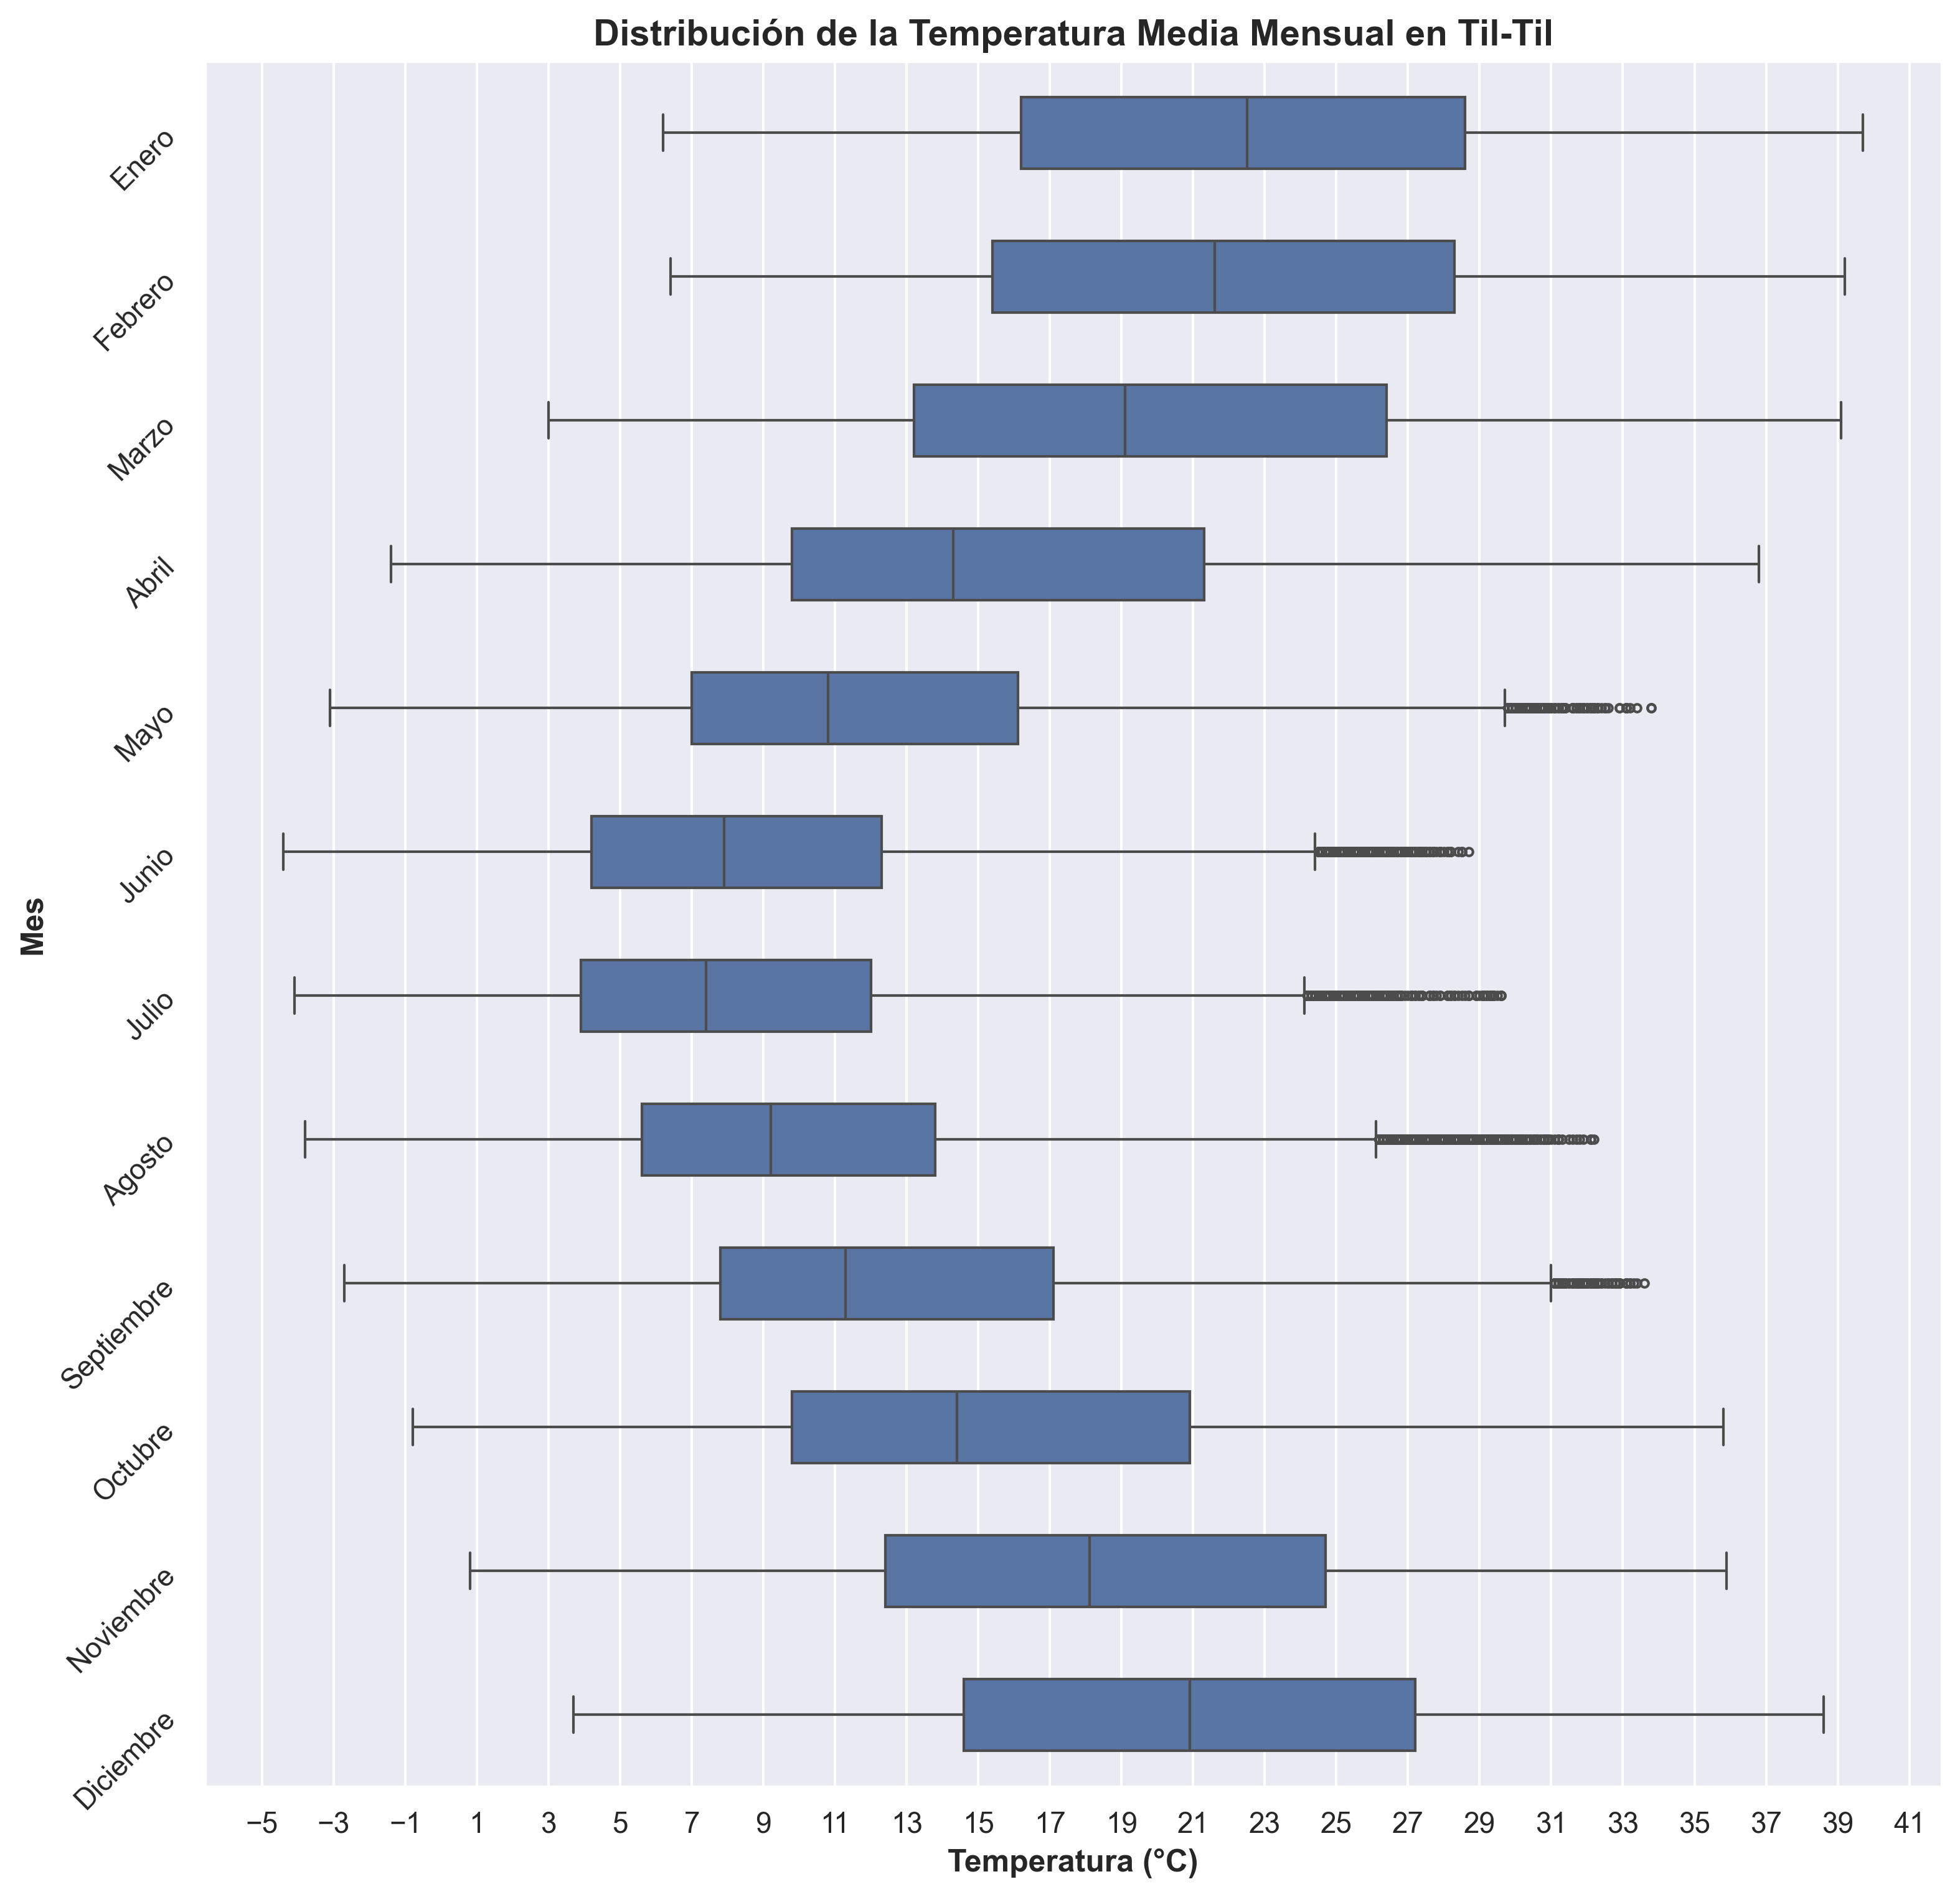

In [51]:
# Boxplot Monthly Avg Temp
plt.figure(figsize=(12, 12))
sns.boxplot(x='avg_temp', y='Month', data=df, orient="h", width=.5, fliersize=3)

plt.yticks(
    ticks=range(0, 12), 
    labels=[months_dict_es[m] for m in range(1, 13)], 
    rotation=45
)

plt.xticks(ticks=range(-5, 42, 2))

plt.title("Distribución de la Temperatura Media Mensual en Til-Til", fontsize=14, fontweight="bold")
plt.xlabel("Temperatura (°C)", fontweight="bold")
plt.ylabel("Mes", fontweight="bold")